# Random Forest

In [15]:
import pandas as pd

df = pd.read_csv("../../data/Heart.csv", index_col=0)
df.head()

,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD
1,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No
2,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes
3,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes
4,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No
5,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No


In [16]:
# kan använda regression på en label/target med null värden för att predicta och fylla dom saknade värdena
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 303 entries, 1 to 303
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        303 non-null    int64  
 1   Sex        303 non-null    int64  
 2   ChestPain  303 non-null    object 
 3   RestBP     303 non-null    int64  
 4   Chol       303 non-null    int64  
 5   Fbs        303 non-null    int64  
 6   RestECG    303 non-null    int64  
 7   MaxHR      303 non-null    int64  
 8   ExAng      303 non-null    int64  
 9   Oldpeak    303 non-null    float64
 10  Slope      303 non-null    int64  
 11  Ca         299 non-null    float64
 12  Thal       301 non-null    object 
 13  AHD        303 non-null    object 
dtypes: float64(2), int64(9), object(3)
memory usage: 35.5+ KB


In [17]:
df = df.drop(columns=["Ca", "Thal"])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 303 entries, 1 to 303
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        303 non-null    int64  
 1   Sex        303 non-null    int64  
 2   ChestPain  303 non-null    object 
 3   RestBP     303 non-null    int64  
 4   Chol       303 non-null    int64  
 5   Fbs        303 non-null    int64  
 6   RestECG    303 non-null    int64  
 7   MaxHR      303 non-null    int64  
 8   ExAng      303 non-null    int64  
 9   Oldpeak    303 non-null    float64
 10  Slope      303 non-null    int64  
 11  AHD        303 non-null    object 
dtypes: float64(1), int64(9), object(2)
memory usage: 30.8+ KB


In [26]:
df.shape

(303, 12)

In [18]:
# relativt balanserat dataset
df["AHD"].value_counts()

AHD
No     164
Yes    139
Name: count, dtype: int64

In [19]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()

,Age,Sex,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,ChestPain_nonanginal,ChestPain_nontypical,ChestPain_typical,AHD_Yes
1,63,1,145,233,1,2,150,0,2.3,3,False,False,True,False
2,67,1,160,286,0,2,108,1,1.5,2,False,False,False,True
3,67,1,120,229,0,2,129,1,2.6,2,False,False,False,True
4,37,1,130,250,0,0,187,0,3.5,3,True,False,False,False
5,41,0,130,204,0,2,172,0,1.4,1,False,True,False,False


In [25]:
df_encoded.shape

(303, 14)

In [20]:
X, y = df_encoded.drop(columns="AHD_Yes"), df_encoded["AHD_Yes"]

X.head(), y.head()

(   Age  Sex  RestBP  Chol  Fbs  RestECG  MaxHR  ExAng  Oldpeak  Slope  \
 1   63    1     145   233    1        2    150      0      2.3      3   
 2   67    1     160   286    0        2    108      1      1.5      2   
 3   67    1     120   229    0        2    129      1      2.6      2   
 4   37    1     130   250    0        0    187      0      3.5      3   
 5   41    0     130   204    0        2    172      0      1.4      1   
 
    ChestPain_nonanginal  ChestPain_nontypical  ChestPain_typical  
 1                 False                 False               True  
 2                 False                 False              False  
 3                 False                 False              False  
 4                  True                 False              False  
 5                 False                  True              False  ,
 1    False
 2     True
 3     True
 4    False
 5    False
 Name: AHD_Yes, dtype: bool)

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

X_train.shape, X_test.shape

((203, 13), (100, 13))

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred[:10]

array([False,  True,  True, False,  True,  True,  True,  True, False,
        True])

In [28]:
y_test[:10].values

array([False,  True,  True,  True,  True,  True,  True,  True,  True,
       False])

              precision    recall  f1-score   support

       False       0.78      0.78      0.78        51
        True       0.78      0.78      0.78        49

    accuracy                           0.78       100
   macro avg       0.78      0.78      0.78       100
weighted avg       0.78      0.78      0.78       100



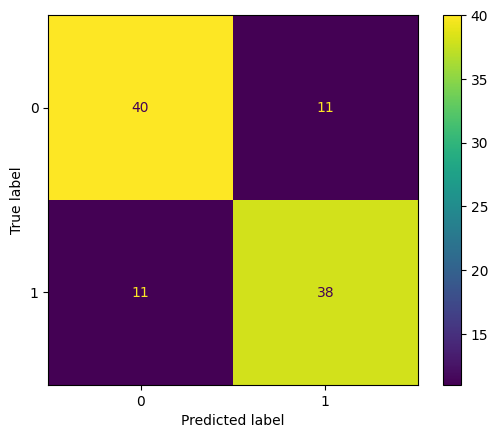

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot();

### Man kan jämföra resultat mellan flera modeller, om 2 modeller predictar false och 1 model predictar true så blir majority vote false

## Feature importance

In [31]:
model.feature_importances_

array([0.14112252, 0.06257674, 0.09922102, 0.10235758, 0.01263623,
       0.02369509, 0.17079483, 0.09178943, 0.12895054, 0.06242244,
       0.05174815, 0.02666014, 0.02602529])

In [37]:
X.columns

Index(['Age', 'Sex', 'RestBP', 'Chol', 'Fbs', 'RestECG', 'MaxHR', 'ExAng',
       'Oldpeak', 'Slope', 'ChestPain_nonanginal', 'ChestPain_nontypical',
       'ChestPain_typical'],
      dtype='object')

In [42]:
feature_importance = pd.DataFrame([X.columns, model.feature_importances_])
feature_importance = feature_importance.T
feature_importance.columns = ["Feature", "Importance"]
feature_importance

,Feature,Importance
0,Age,0.141123
1,Sex,0.062577
2,RestBP,0.099221
3,Chol,0.102358
4,Fbs,0.012636
5,RestECG,0.023695
6,MaxHR,0.170795
7,ExAng,0.091789
8,Oldpeak,0.128951
9,Slope,0.062422


In [55]:
feature_importance = feature_importance.sort_values(by= "Importance", ascending=False)
feature_importance

,Feature,Importance
6,MaxHR,0.170795
0,Age,0.141123
8,Oldpeak,0.128951
3,Chol,0.102358
2,RestBP,0.099221
7,ExAng,0.091789
1,Sex,0.062577
9,Slope,0.062422
10,ChestPain_nonanginal,0.051748
11,ChestPain_nontypical,0.02666


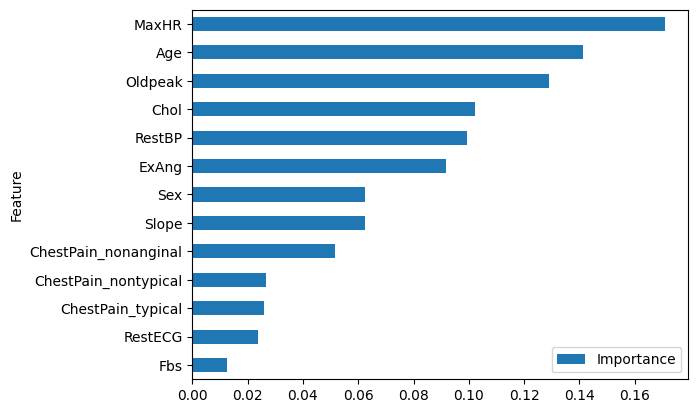

In [56]:
ax = feature_importance.plot(x="Feature", y="Importance", kind="barh")
ax.invert_yaxis()